# Cap. 03 — Introducción a los Algoritmos Cuánticos
## Listing 3-3: Mediciones tras una transformada Hadamard en un qubit (Qiskit)

**Referencia:** Pattanayak, *Quantum Machine Learning with Python*, Capítulo 3, Listing 3-3.

Equivalente en Qiskit del Listing 3-1 (Cirq): un qubit en |0⟩ pasa por Hadamard y se mide 100 veces.

### Diferencias de API respecto al libro (Qiskit 1.0+)

| Libro (API antigua) | Este notebook (Qiskit ≥1.0) |
|---|---|
| `from qiskit import execute, Aer` | `from qiskit_aer import AerSimulator` |
| `Aer.get_backend('qasm_simulator')` | `AerSimulator()` |
| `execute(circuit, simulator, shots=n)` | `simulator.run(transpile(circuit, simulator), shots=n)` |

### Definición del circuito

In [1]:
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram

# 1 qubit, 1 bit clásico para almacenar la medición
circuit = QuantumCircuit(1, 1)
circuit.h(0)
circuit.measure([0], [0])

print(circuit.draw(output='text'))

     ┌───┐┌─┐
  q: ┤ H ├┤M├
     └───┘└╥┘
c: 1/══════╩═
           0 


### Visualización del circuito

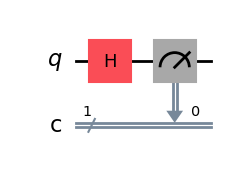

In [2]:
circuit.draw('mpl')

### Simulación

In [3]:
simulator = AerSimulator()
compiled = transpile(circuit, simulator)
job = simulator.run(compiled, shots=100)
result = job.result()
counts = result.get_counts()

print("Conteo total para |0⟩ y |1⟩:", counts)

Conteo total para |0⟩ y |1⟩: {'0': 53, '1': 47}


### Histograma de mediciones

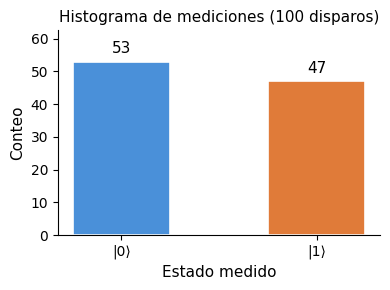

In [4]:
from qml_santanu.common.plot_utils import plot_counts

plot_counts(counts)